In [12]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [13]:
DATASET = 'iris'   # 'iris' or 'wine'
GRID = 10         
ITERS = 1000      
VERBOSE = False    
SEED = 42

np.random.seed(SEED)

In [ ]:
class KSOM:
    def __init__(self, m=10, n=10, dim=4, sigma=None, learning_rate=0.5, seed=42):
        self.m = m
        self.n = n
        self.dim = dim
        self.learning_rate_initial = learning_rate
        self.sigma_initial = sigma if sigma is not None else max(m, n) / 2.0
        self.rng = np.random.RandomState(seed)
        self.weights = self.rng.rand(m, n, dim)
        self._neuron_locations = np.array([[(i, j) for j in range(n)] for i in range(m)])

    def _find_bmu(self, x):
        diff = self.weights - x
        dist_sq = np.sum(diff ** 2, axis=2)
        bmu_idx = np.unravel_index(np.argmin(dist_sq, axis=None), dist_sq.shape)
        return bmu_idx

    def _decay_radius(self, iteration, num_iterations):
        denom = (num_iterations / math.log(max(self.sigma_initial, 1.0001)))
        return self.sigma_initial * math.exp(-iteration / denom)

    def _decay_learning_rate(self, iteration, num_iterations):
        return self.learning_rate_initial * math.exp(-iteration / num_iterations)

    def _neighborhood_function(self, dist_sq, sigma):
        return np.exp(-dist_sq / (2 * (sigma ** 2) + 1e-12))

    def train(self, data, num_iterations=1000, verbose=False):
        num_data = data.shape[0]
        for it in range(num_iterations):
            x = data[np.random.randint(0, num_data)]
            bmu_idx = self._find_bmu(x)
            bmu_loc = np.array(bmu_idx)
            sigma = self._decay_radius(it, num_iterations)
            lr = self._decay_learning_rate(it, num_iterations)
            locs = self._neuron_locations
            dist_sq = (locs[:, :, 0] - bmu_loc[0]) ** 2 + (locs[:, :, 1] - bmu_loc[1]) ** 2
            h = self._neighborhood_function(dist_sq, sigma)
            delta = lr * h[:, :, np.newaxis] * (x - self.weights)
            self.weights += delta
            if verbose and (it + 1) % max(1, (num_iterations // 5)) == 0:
                print(f"[kSOM] Iter {it+1}/{num_iterations} lr={lr:.4f} sigma={sigma:.4f}")

    def map_vects(self, data):
        mapped = np.zeros((data.shape[0], 2), dtype=int)
        for idx, x in enumerate(data):
            bmu = self._find_bmu(x)
            mapped[idx, :] = bmu
        return mapped

    def u_matrix(self):
        um = np.zeros((self.m, self.n))
        for i in range(self.m):
            for j in range(self.n):
                neighbors = []
                for di in (-1, 0, 1):
                    for dj in (-1, 0, 1):
                        ni, nj = i + di, j + dj
                        if 0 <= ni < self.m and 0 <= nj < self.n and not (di == 0 and dj == 0):
                            neighbors.append(self.weights[ni, nj])
                if neighbors:
                    dists = [np.linalg.norm(self.weights[i, j] - nb) for nb in neighbors]
                    um[i, j] = np.mean(dists)
        return um

In [15]:
def plot_som_mapping(som, data, labels=None, title="SOM mapping", figsize=(6,6)):
    mapped = som.map_vects(data)
    plt.figure(figsize=figsize)
    ax = plt.gca()
    for i in range(som.m):
        for j in range(som.n):
            ax.scatter(i, j, marker='s', s=80, facecolors='none', edgecolors='lightgray')
    if labels is None:
        ax.scatter(mapped[:,0], mapped[:,1], c='k', s=24, alpha=0.7)
    else:
        sc = ax.scatter(mapped[:,0], mapped[:,1], c=labels, cmap='tab10', s=40, alpha=0.85)
        plt.colorbar(sc, label='class')
    ax.set_title(title)
    ax.set_xlim(-1, som.m)
    ax.set_ylim(-1, som.n)
    ax.set_xlabel('SOM X'); ax.set_ylabel('SOM Y')
    ax.invert_yaxis()
    plt.tight_layout()

In [16]:
def plot_u_matrix(som, title='U-Matrix', figsize=(6,6)):
    um = som.u_matrix()
    plt.figure(figsize=figsize)
    plt.imshow(um.T, origin='lower')
    plt.colorbar(label='mean neighbor distance')
    plt.title(title)
    plt.xlabel('SOM X'); plt.ylabel('SOM Y')
    plt.tight_layout()

In [17]:
def plot_projection_vs_pca(data, labels, som, title_prefix='kSOM', figsize=(10,4)):
    mapped = som.map_vects(data).astype(float)
    mapped_x = mapped[:,0] + np.random.uniform(-0.3,0.3,size=mapped.shape[0])
    mapped_y = mapped[:,1] + np.random.uniform(-0.3,0.3,size=mapped.shape[0])
    pca = PCA(n_components=2)
    data_pca = pca.fit_transform(data)
    plt.figure(figsize=figsize)
    plt.subplot(1,2,1)
    sc1 = plt.scatter(mapped_x, mapped_y, c=labels, cmap='tab10', s=30)
    plt.title(f'{title_prefix} projection (BMU coords)')
    plt.gca().invert_yaxis()
    plt.colorbar(sc1, label='class')
    plt.subplot(1,2,2)
    sc2 = plt.scatter(data_pca[:,0], data_pca[:,1], c=labels, cmap='tab10', s=30)
    plt.title('PCA (2D)')
    plt.colorbar(sc2, label='class')
    plt.tight_layout()

In [18]:
if DATASET == 'iris':
    ds = datasets.load_iris()
elif DATASET == 'wine':
    ds = datasets.load_wine()
else:
    raise ValueError("Unknown DATASET value")

data = ds.data
labels = ds.target
scaler = StandardScaler()
data_n = scaler.fit_transform(data)

== Part A: kSOM (from scratch) ==


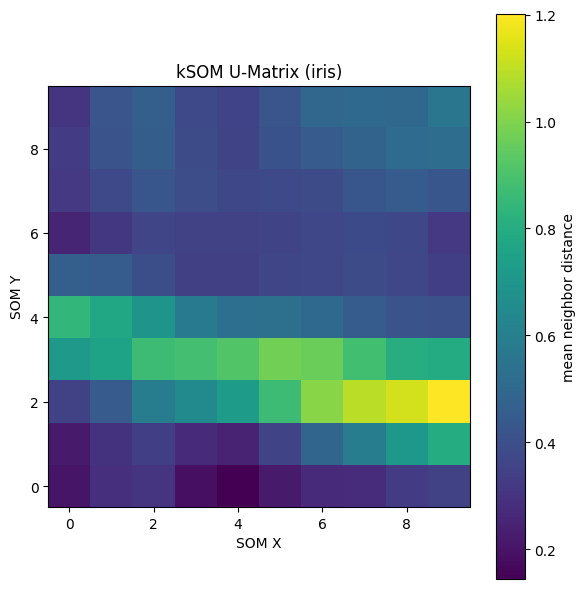

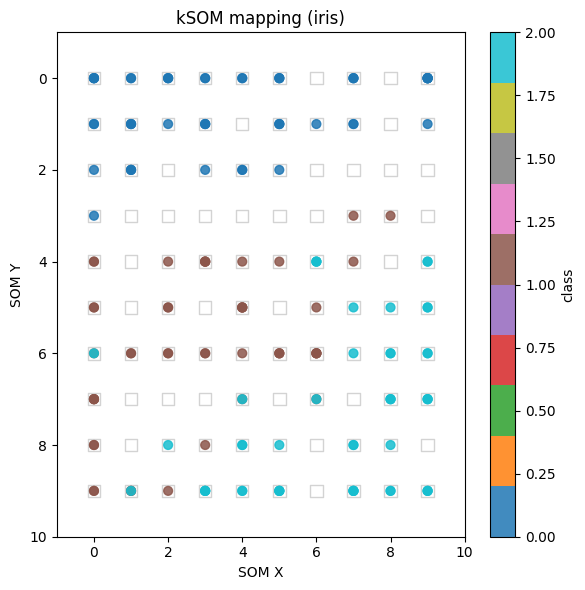

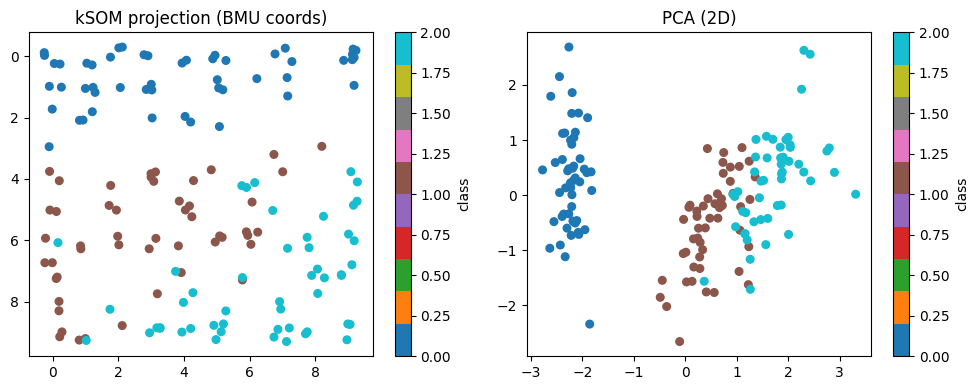

In [19]:
print("== Part A: kSOM (from scratch) ==")
som = KSOM(m=GRID, n=GRID, dim=data_n.shape[1], sigma=None, learning_rate=0.5, seed=SEED)
som.train(data_n, num_iterations=ITERS, verbose=VERBOSE)

plot_u_matrix(som, title=f'kSOM U-Matrix ({DATASET})')
plot_som_mapping(som, data_n, labels=labels, title=f'kSOM mapping ({DATASET})')
plot_projection_vs_pca(data_n, labels, som, title_prefix='kSOM')
plt.show()